Importing Libraries


In [1]:
%pip install scikit-learn==1.3.2 --no-cache-dir

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import matplotlib

Load the telco-customer-churn dataset

In [3]:
df=pd.read_csv(r"C:\Users\DELL\OneDrive\Documents\8SEM INTERNSHIP PROJECT\anurag project antivirus\Churn_project\data\Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


EDA

In [4]:
df.drop(['SeniorCitizen','Partner','Dependents','OnlineBackup','PhoneService','MultipleLines','InternetService','OnlineSecurity','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','PaperlessBilling','PaymentMethod'],axis=1,inplace=True)

In [5]:
df.head()

,customerID,gender,tenure,Contract,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,1,Month-to-month,29.85,29.85,No
1,5575-GNVDE,Male,34,One year,56.95,1889.5,No
2,3668-QPYBK,Male,2,Month-to-month,53.85,108.15,Yes
3,7795-CFOCW,Male,45,One year,42.30,1840.75,No
4,9237-HQITU,Female,2,Month-to-month,70.70,151.65,Yes


In [6]:
df.shape

(7043, 7)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customerID      7043 non-null   object 
 1   gender          7043 non-null   object 
 2   tenure          7043 non-null   int64  
 3   Contract        7043 non-null   object 
 4   MonthlyCharges  7043 non-null   float64
 5   TotalCharges    7043 non-null   object 
 6   Churn           7043 non-null   object 
dtypes: float64(1), int64(1), object(5)
memory usage: 385.3+ KB


In [8]:
df.isnull().sum()

customerID        0
gender            0
tenure            0
Contract          0
MonthlyCharges    0
TotalCharges      0
Churn             0
dtype: int64

In [9]:
df.describe()

,tenure,MonthlyCharges
count,7043.000000,7043.000000
mean,32.371149,64.761692
std,24.559481,30.090047
min,0.000000,18.250000
25%,9.000000,35.500000
50%,29.000000,70.350000
75%,55.000000,89.850000
max,72.000000,118.750000


In [10]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [11]:
df.describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000


In [12]:
df['TotalCharges'].isnull().sum()

11

In [13]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['MonthlyCharges'] * df['tenure'])

In [14]:
df['TotalCharges'].isnull().sum()

0

In [15]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [16]:
df['gender'].value_counts()

gender
Male      3555
Female    3488
Name: count, dtype: int64

In [17]:
df.duplicated().sum()

0

In [18]:
df = df.drop('customerID', axis=1)

In [19]:
numeric_columns=['tenure','MonthlyCharges','TotalCharges']
categorical_columns=['gender','Contract','Churn']

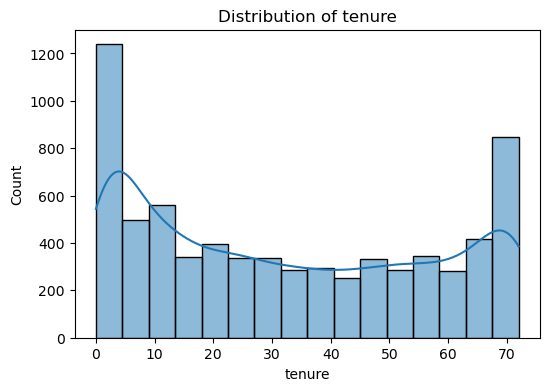

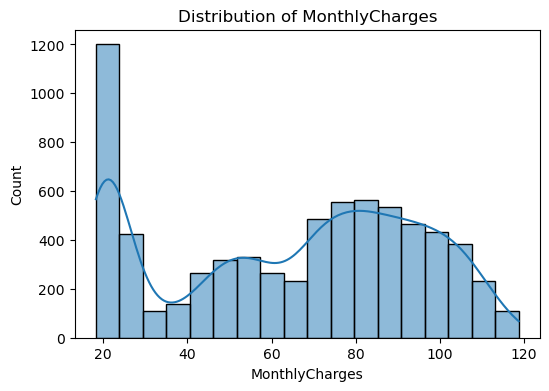

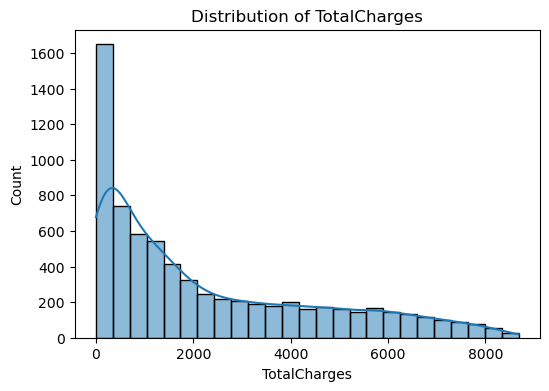

In [20]:
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

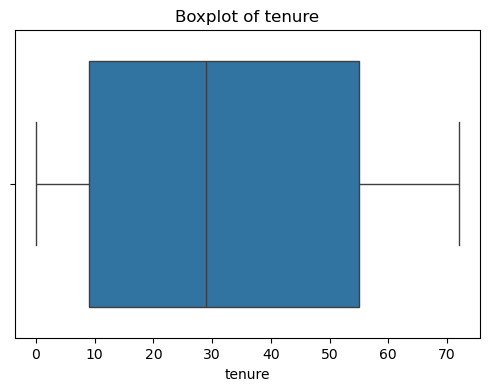

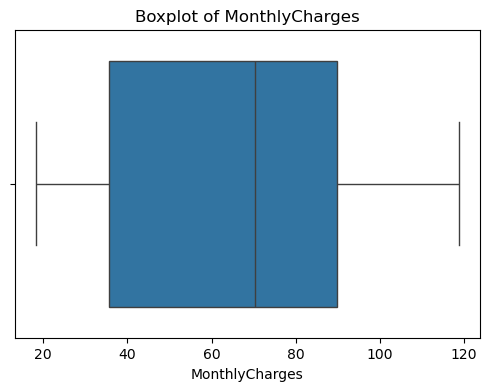

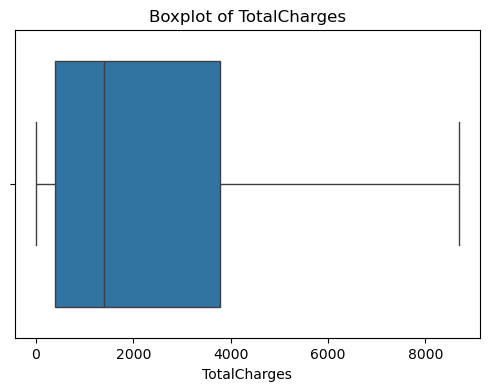

In [21]:
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

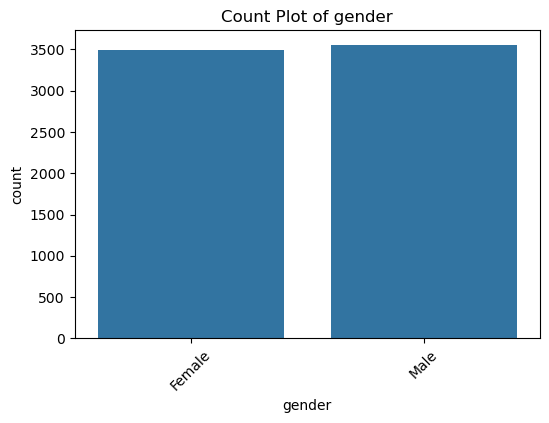

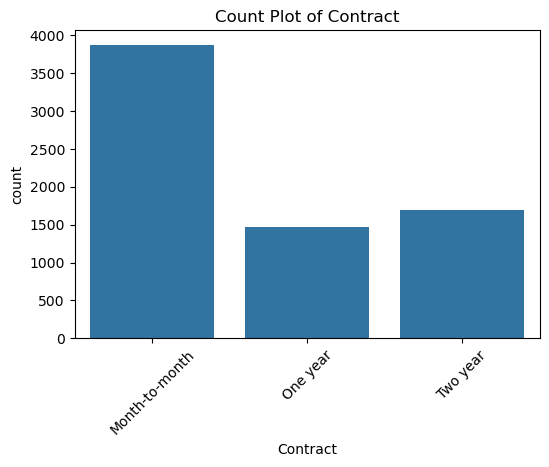

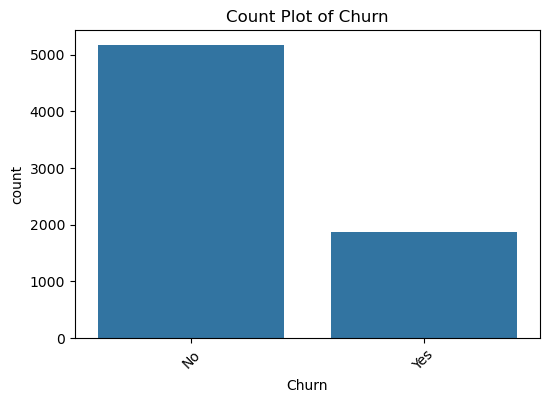

In [22]:
for col in categorical_columns:
    plt.figure(figsize=(6,4))
    sns.countplot(x=df[col])
    plt.title(f"Count Plot of {col}")
    plt.xticks(rotation=45)
    plt.show()

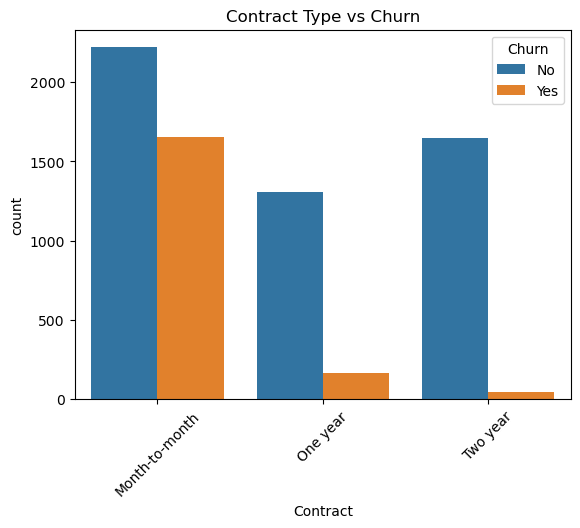

In [23]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Contract Type vs Churn")
plt.xticks(rotation=45)
plt.show()

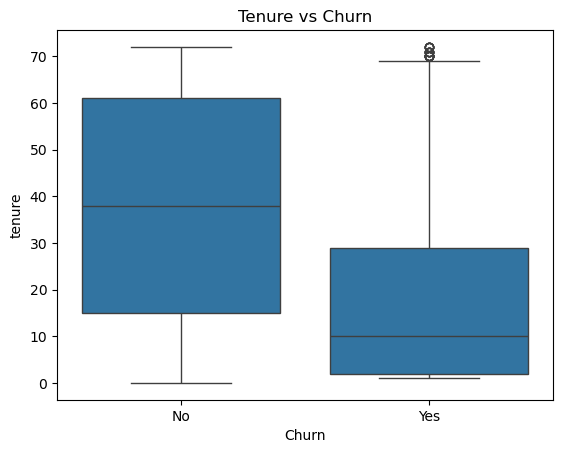

In [24]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()

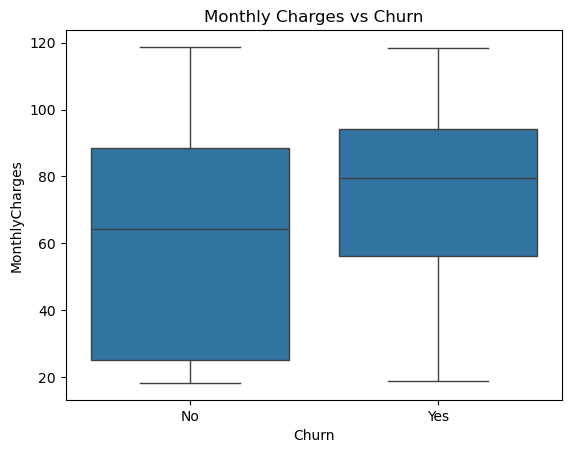

In [25]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

In [26]:
df['Churn'] = df['Churn'].map({'Yes':1,'No':0})

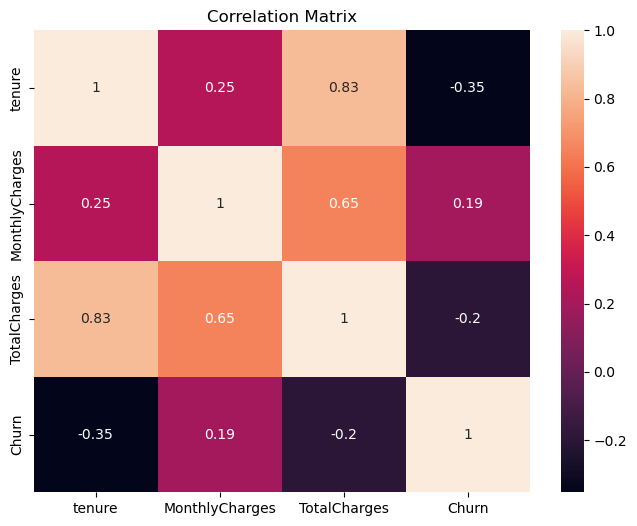

In [27]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.title("Correlation Matrix")
plt.show()

Data Preprocessing 

In [28]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [29]:
X.select_dtypes(include='object').columns

Index(['gender', 'Contract'], dtype='object')

In [30]:
df['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [31]:
X = pd.get_dummies(X, drop_first=True,dtype=int)

In [32]:
X.head()

,tenure,MonthlyCharges,TotalCharges,gender_Male,Contract_One year,Contract_Two year
0,1,29.85,29.85,0,0,0
1,34,56.95,1889.50,1,1,0
2,2,53.85,108.15,1,0,0
3,45,42.30,1840.75,1,1,0
4,2,70.70,151.65,0,0,0


Train Test Split

In [33]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Scaled the X_trian , X_test

In [34]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [35]:
print(X_train.shape)
print(X_test.shape)

(5634, 6)
(1409, 6)


# Model Comparison

Logistic regression

In [36]:
from sklearn.linear_model import LogisticRegression
model_lr = LogisticRegression()
model_lr.fit(X_train, y_train)

LogisticRegression()

In [37]:
y_pred_lr = model_lr.predict(X_test)

In [38]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred_lr)
print("Accuracy:", accuracy)

Accuracy: 0.801277501774308


In [39]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1036
           1       0.66      0.52      0.58       373

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



In [40]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_lr)
print(cm)

[[935 101]
 [179 194]]


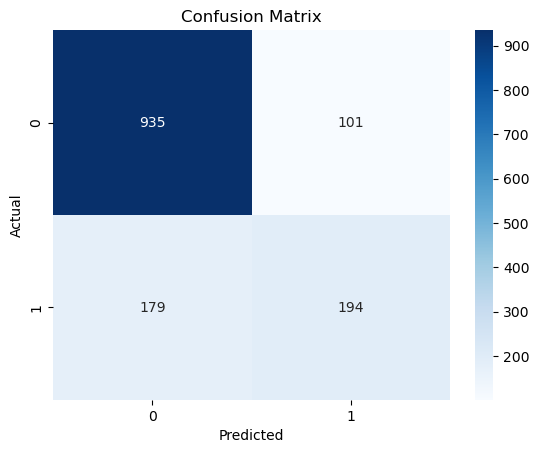

In [41]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [42]:
y.value_counts ()

Churn
0    5174
1    1869
Name: count, dtype: int64

Tune the logistic Regression model

In [43]:
model=LogisticRegression(class_weight='balanced')

In [44]:
model.fit(X_train,y_train)

LogisticRegression(class_weight='balanced')

In [45]:
y_pred = model.predict(X_test)

In [46]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7224982256919801


In [47]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.66      0.78      1036
           1       0.49      0.89      0.63       373

    accuracy                           0.72      1409
   macro avg       0.72      0.78      0.70      1409
weighted avg       0.82      0.72      0.74      1409



In [48]:
cm_updated = confusion_matrix(y_test, y_pred)
print(cm_updated)

[[686 350]
 [ 41 332]]


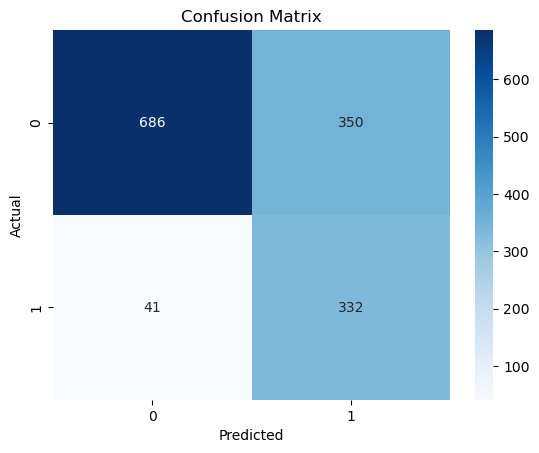

In [49]:
sns.heatmap(cm_updated, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

KNN model

In [50]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [51]:
y_pred_knn = knn.predict(X_test)

In [52]:
accuracy = accuracy_score(y_test, y_pred_knn)
print("Accuracy:", accuracy)

Accuracy: 0.7934705464868701


In [53]:
print("KNN Results:\n")
print(classification_report(y_test, y_pred_knn))
cm_knn = confusion_matrix(y_test, y_pred_knn)
print(cm_knn)

KNN Results:

              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1036
           1       0.63      0.54      0.58       373

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409

[[915 121]
 [170 203]]


Random forest model

In [54]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [55]:
y_pred_rf = rf.predict(X_test)

In [56]:
accuracy = accuracy_score(y_test, y_pred_rf)
print("Accuracy:", accuracy)

Accuracy: 0.7806955287437899


In [57]:
print("Random Forest Results:\n")
print(classification_report(y_test, y_pred_rf))
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)

Random Forest Results:

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1036
           1       0.61      0.49      0.54       373

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409

[[919 117]
 [192 181]]


Tune the random forest model

In [58]:
rf_updated= RandomForestClassifier(class_weight='balanced',random_state=42)
rf_updated.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [59]:
y_pred_rf_updated = rf_updated.predict(X_test)

In [60]:
accuracy = accuracy_score(y_test, y_pred_rf_updated)
print("Accuracy:", accuracy)

Accuracy: 0.7721788502484032


In [61]:
print("Random Forest Updated Results:\n")
print(classification_report(y_test, y_pred_rf_updated))
cm_rf_updated = confusion_matrix(y_test, y_pred_rf_updated)
print(cm_rf_updated)

Random Forest Updated Results:

              precision    recall  f1-score   support

           0       0.82      0.88      0.85      1036
           1       0.58      0.48      0.53       373

    accuracy                           0.77      1409
   macro avg       0.70      0.68      0.69      1409
weighted avg       0.76      0.77      0.76      1409

[[908 128]
 [193 180]]


## Final Model Selection

After comparing multiple models, Logistic Regression with class_weight='balanced' was selected as the final model because it achieved the highest recall for churn prediction (~0.89), which is critical for minimizing customer loss.

Although Random Forest and KNN provided competitive accuracy, they performed poorly in detecting churn cases.

In [62]:
y_probs = model.predict_proba(X_test)[:,1]
y_pred = (y_probs > 0.3).astype(int)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[526 510]
 [ 17 356]]
              precision    recall  f1-score   support

           0       0.97      0.51      0.67      1036
           1       0.41      0.95      0.57       373

    accuracy                           0.63      1409
   macro avg       0.69      0.73      0.62      1409
weighted avg       0.82      0.63      0.64      1409



In [63]:
import pickle
pickle.dump(model, open("model.pkl","wb"))

In [64]:
pickle.dump(scaler, open("scaler.pkl","wb"))

In [65]:
print("numpy", np.__version__)
print("pandas", pd.__version__)
print("sklearn", sklearn.__version__)
print("Matplotlib", matplotlib.__version__)
print("seaborn", sns.__version__)

numpy 1.26.4
pandas 2.1.4
sklearn 1.3.2
Matplotlib 3.8.0
seaborn 0.13.2
